# Exploratory Data Analysis: 2025 AI Index Report (8 Topics)

This notebook explores the public dataset from the **2025 AI Index Report** to support a datathon project in **Education & Digital Equity** or **Civic Engagement & Policy**.

**8 report sections:**  
1. Research and Development | 2. Technical Performance | 3. Responsible AI | 4. Economy | 5. Science and Medicine | 6. Policy and Governance | 7. Education | 8. Public Opinion

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path("data/PUBLIC DATA_ 2025 AI Index Report")
sns.set_theme(style="whitegrid")

---
## 1. Education (Topic 7) — *Education & Digital Equity*

Key files: CS by continent, state-level CS offerings, AP CS by race/gender (equity), CS graduates over time.

CS education % by continent:


,% of countries offering CS education,Continent,Year
0,9%,Africa,2019
1,25%,Asia,2019
2,63%,Europe,2019
3,30%,LAC,2019
4,49%,Africa,2024
5,58%,Asia,2024
6,89%,Europe,2024
7,70%,LAC,2024


TypeError: no numeric data to plot

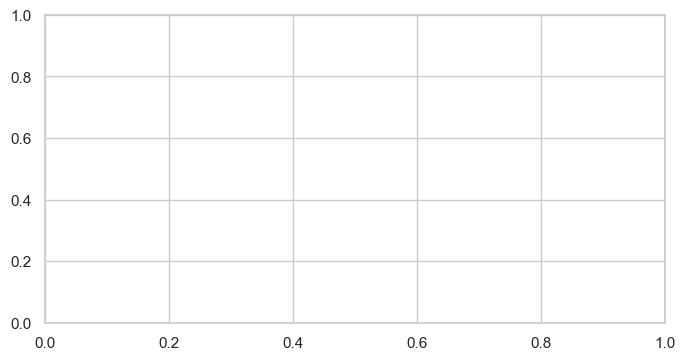

In [11]:
# CS education coverage by continent (2019 vs 2024)
edu_continent = pd.read_csv(BASE / "7. Education/Data/fig_7.2.18.csv")
edu_continent.columns = [c.strip() for c in edu_continent.columns]
print("CS education % by continent:")
display(edu_continent)

pivot_edu = edu_continent.pivot(index="Continent", columns="Year", values=edu_continent.columns[0])
pivot_edu.plot(kind="bar", figsize=(8,4), title="% of countries offering CS education by continent")
plt.xticks(rotation=0)
plt.ylabel("% of countries")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

Ratio of AP CS participation to national demographics (1 = proportional):


,Ratio of AP CS exam participation to national demographics,Race/ethnicity,Gender,ratio
0,7.87,Asian,Male,7.87
1,0.59,Black/African American,Male,0.59
2,0.86,Hispanic/Latino/Latina/Latinx,Male,0.86
3,0.44,Native American/Alaskan,Male,0.44
4,0.29,Native Hawaiian/Pacific Islander,Male,0.29
5,1.30,Two or more races,Male,1.30
6,1.28,White,Male,1.28
7,4.18,Asian,Female,4.18
8,0.35,Black/African American,Female,0.35
9,0.41,Hispanic/Latino/Latina/Latinx,Female,0.41


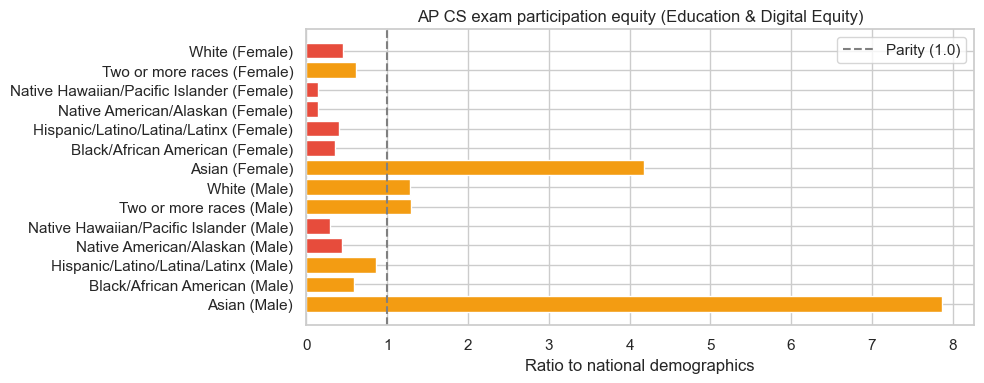

In [13]:
# AP CS exam participation ratio vs national demographics (equity metric)
equity_ratio = pd.read_csv(BASE / "7. Education/Data/fig_7.2.12.csv")
equity_ratio.columns = [c.strip() for c in equity_ratio.columns]
ratio_col = equity_ratio.columns[0]
equity_ratio["ratio"] = pd.to_numeric(equity_ratio[ratio_col], errors="coerce")
print("Ratio of AP CS participation to national demographics (1 = proportional):")
display(equity_ratio)

fig, ax = plt.subplots(figsize=(10,4))
labels = equity_ratio["Race/ethnicity"] + " (" + equity_ratio["Gender"] + ")"
r_vals = equity_ratio["ratio"]
colors = ['#2ecc71' if 0.9 <= r <= 1.1 else '#e74c3c' if r < 0.5 else '#f39c12' for r in r_vals]
ax.barh(labels, r_vals, color=colors)
ax.axvline(1, color='gray', linestyle='--', label='Parity (1.0)')
ax.set_xlabel("Ratio to national demographics")
ax.set_title("AP CS exam participation equity (Education & Digital Equity)")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# State-level: % high schools teaching foundational CS
state_cs = pd.read_csv(BASE / "7. Education/Data/fig_7.2.1.csv")
state_cs.columns = [c.strip() for c in state_cs.columns]
state_cs["pct_numeric"] = state_cs.iloc[:,1].str.replace("%", "").astype(float)
print("State-level CS offerings (summary):")
print(state_cs["pct_numeric"].describe())
state_cs.sort_values("pct_numeric", ascending=True).head(10)

State-level CS offerings (summary):
count     51.000000
mean      65.764706
std       18.501447
min       31.000000
25%       52.000000
50%       61.000000
75%       82.000000
max      100.000000
Name: pct_numeric, dtype: float64


,State code,% public high schools teaching foundational CS,State name,pct_numeric
26,MT,31%,Montana,31.0
16,KS,35%,Kansas,35.0
23,MN,36%,Minnesota,36.0
9,FL,38%,Florida,38.0
18,LA,39%,Louisiana,39.0
2,AZ,43%,Arizona,43.0
12,ID,46%,Idaho,46.0
34,ND,47%,North Dakota,47.0
47,WA,50%,Washington,50.0
41,SD,51%,South Dakota,51.0


---
## 2. Policy and Governance (Topic 6) — *Civic Engagement & Policy*

AI-related bills by country; US agency regulations; public spending on AI.

Top 15 countries by AI-related bills passed (2016-24):


,Geographic area,"Number of AI-related bills passed into law, 2016-24"
115,United States,27
114,Portugal,20
113,Russia,20
112,Belgium,18
111,"Korea, Rep",13
110,Spain,11
108,United Kingdom,10
109,Italy,10
107,France,9
106,Austria,7


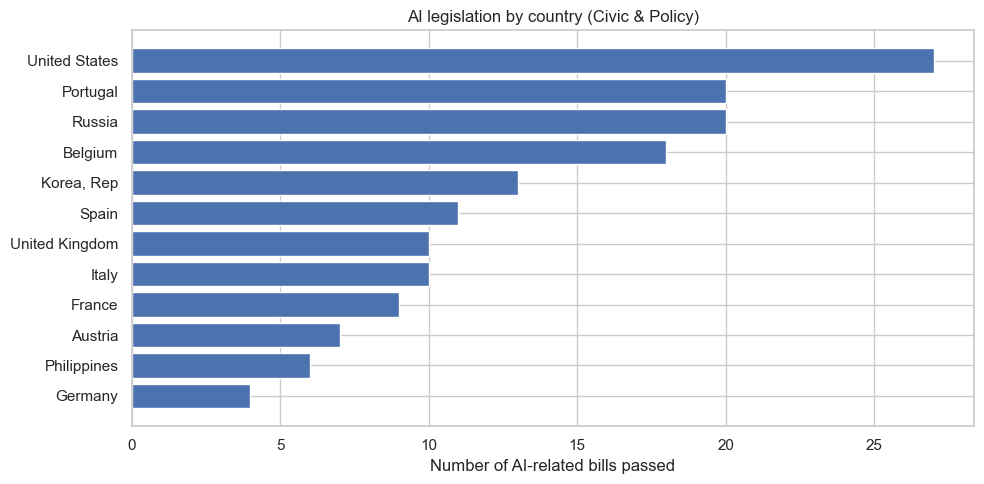

In [7]:
# AI-related bills passed into law by country (2016-24)
bills = pd.read_csv(BASE / "6. Policy and Governance/Data/fig_6.2.1.csv")
bills.columns = [c.strip() for c in bills.columns]
col = bills.columns[1]
bills_sorted = bills.sort_values(col, ascending=False)
print("Top 15 countries by AI-related bills passed (2016-24):")
display(bills_sorted.head(15))

top = bills_sorted.head(12)
plt.figure(figsize=(10,5))
plt.barh(top["Geographic area"].str[:20], top[col])
plt.xlabel("Number of AI-related bills passed")
plt.title("AI legislation by country (Civic & Policy)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# US federal agency AI-related regulations (count by agency/year)
regs = pd.read_csv(BASE / "6. Policy and Governance/Data/fig_6.2.20.csv")
regs.columns = [c.strip() for c in regs.columns]
reg_by_yr = regs.groupby("Year")["Number of AI-related regulations"].sum()
print("Total US federal AI-related regulations by year:")
print(reg_by_yr)
reg_by_yr.plot(kind="bar", figsize=(8,3), title="US federal AI regulations by year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

---
## 3. Public Opinion (Topic 8) — *Civic & Policy*

Policy preferences (agree/neutral/disagree); trust and understanding of AI.

Policy support (Agree %):


,Policy,pct
0,Stricter data privacy regulations,80.4
1,Retraining for unemployed,76.2
2,AI deployment regulations,72.5
3,Stronger antitrust,57.7
4,Parole and sentencing AI regulations,54.7
5,Bias audits for hiring and promotion AI,51.7
6,Stronger social safety net,46.4
7,Federal regulations on local government AI,45.6
8,Semiconductor and AI hardware subsidies,44.4
9,Higher corporate income taxes,42.9


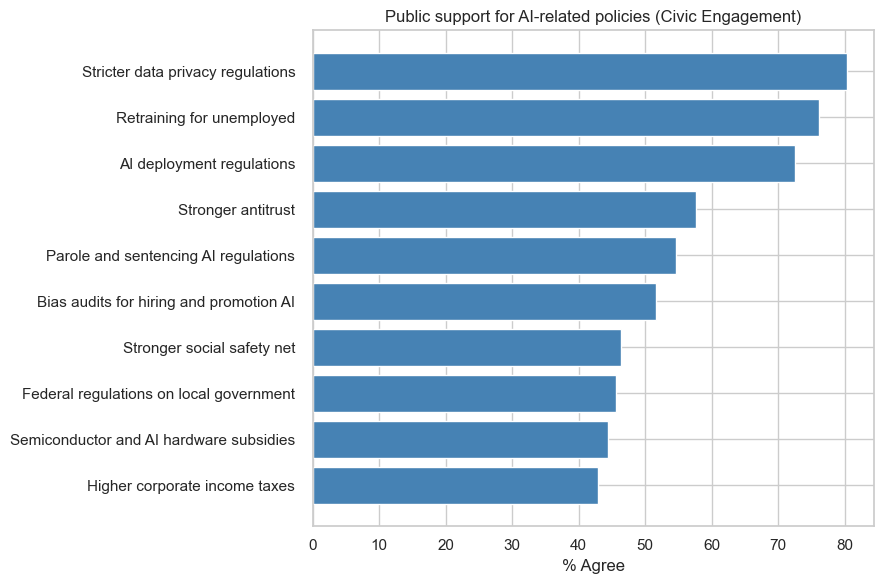

In [8]:
# Public support for AI-related policies
opinion = pd.read_csv(BASE / "8. Public Opinion/Data/fig_8.2.2.csv")
opinion.columns = [c.strip() for c in opinion.columns]
opinion["pct"] = opinion["% of respondents"].str.replace("%", "").astype(float)
agree = opinion[opinion["Label"] == "Agree"].sort_values("pct", ascending=False)
print("Policy support (Agree %):")
display(agree[["Policy", "pct"]].head(10))

fig, ax = plt.subplots(figsize=(9,6))
agree_plot = agree.head(10)
ax.barh(agree_plot["Policy"].str[:40], agree_plot["pct"], color='steelblue')
ax.set_xlabel("% Agree")
ax.set_title("Public support for AI-related policies (Civic Engagement)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Trust/understanding by year (sample):


Year,2022,2023,2024
Opinion on products and services using AI,,,
I have a good understanding of what artificial intelligence is,64.0,67.0,67.0
I know which types of products and services use artificial intelligence,50.0,51.0,52.0
I trust artificial intelligence to not discriminate or show bias toward any group of people,NaN,56.0,54.0
I trust people not to discriminate or show bias toward any group of people,NaN,NaN,45.0
I trust that companies that use artificial intelligence will protect my personal data,NaN,50.0,47.0


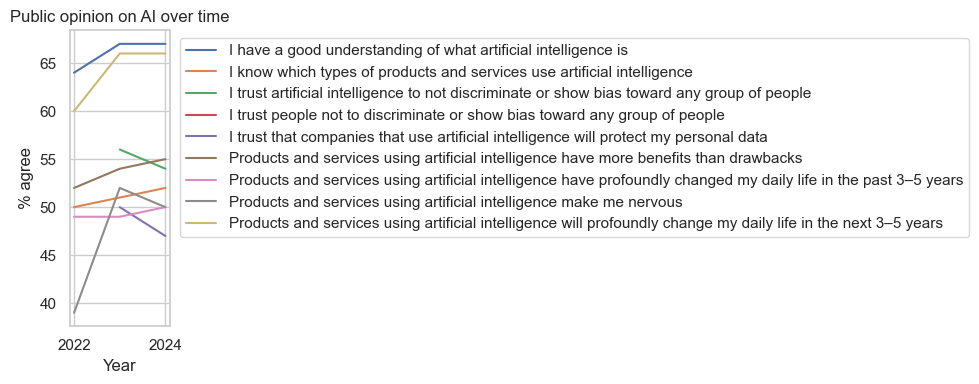

In [12]:
# Trust and understanding over time
trust = pd.read_csv(BASE / "8. Public Opinion/Data/fig_8.1.1.csv")
trust.columns = [c.strip() for c in trust.columns]
pct_col = [c for c in trust.columns if "agree" in c.lower() and "%" in c][0]
trust["pct"] = trust[pct_col].astype(str).str.replace("%", "").astype(float)
pivot_trust = trust.pivot_table(index="Opinion on products and services using AI", columns="Year", values="pct")
print("Trust/understanding by year (sample):")
display(pivot_trust.head())
pivot_trust.T.plot(figsize=(10,4), title="Public opinion on AI over time")
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.ylabel("% agree")
plt.tight_layout()
plt.show()

---
## 4. Economy (Topic 4) — Supporting context

AI adoption by industry/function; AI job postings by sector.

AI job postings share by sector (2024):


,Sector,pct
29,Information,9.33
28,"Professional, scientific, and technical services",5.25
27,Finance and insurance,3.76
26,Manufacturing,3.75
25,Utilities,2.15
24,Educational services,2.05
23,Management of companies and enterprises,1.92
22,"Mining, quarrying, and oil and gas extraction",1.87
21,Public administration,1.29
20,Real estate and rental and leasing,1.21


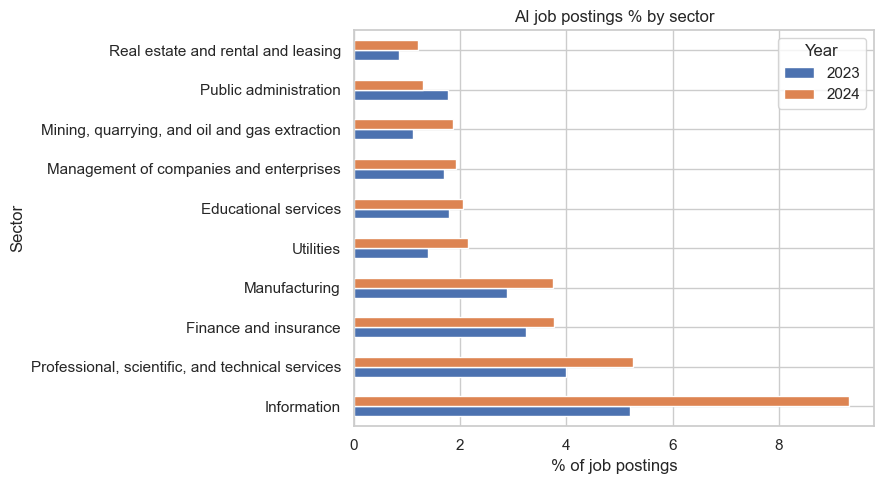

In [10]:
# AI job postings % by sector (2023 vs 2024)
jobs = pd.read_csv(BASE / "4. Economy/Data/fig_4.2.7.csv")
jobs.columns = [c.strip() for c in jobs.columns]
jobs["pct"] = jobs["AI Job Postings (% of All Job Postings)"].str.replace("%", "").astype(float)
sectors_24 = jobs[jobs["Year"]==2024].sort_values("pct", ascending=False)
print("AI job postings share by sector (2024):")
display(sectors_24[["Sector", "pct"]].head(10))

wide = jobs.pivot(index="Sector", columns="Year", values="pct")
wide["change"] = wide[2024] - wide[2023]
wide = wide.sort_values(2024, ascending=False).head(10)
wide[[2023, 2024]].plot(kind="barh", figsize=(9,5), title="AI job postings % by sector")
plt.xlabel("% of job postings")
plt.tight_layout()
plt.show()

---
## 5. Cross-topic summary for project ideas

| Topic | Key variables | Best for category |
|-------|----------------|--------------------|
| **7. Education** | Continent/state CS %, AP CS ratio by race/gender, state offerings | **Education & Digital Equity** |
| **6. Policy** | Bills by country, US agency regulations, spending by department | **Civic Engagement & Policy** |
| **8. Public Opinion** | Policy agree/disagree, trust, understanding by year | **Civic Engagement & Policy** |
| **4. Economy** | Adoption by industry/function, job postings by sector | Supporting (policy effectiveness, labor impact) |

**Possible joins / ML targets:**
- Education: Predict **at-risk states** (low CS access) or **equity ratio** from state/regional features.
- Policy: **Policy–public alignment** (compare enacted laws vs public opinion); predict **support** for a policy from policy type.
- Cross: Predict **CS participation or equity** from policy/spending/context (Education + Policy).